In [1]:
# !pip install ucimlrepo

In [2]:
from ucimlrepo import fetch_ucirepoimport pandas as pdimport matplotlib.pyplot as pltimport numpy as npimport seaborn as snsimport warningsfrom sklearn.preprocessing import MinMaxScalerfrom sklearn.decomposition import PCA # to visualize high dimensional datafrom sklearn.manifold import TSNEfrom sklearn.metrics import adjusted_rand_score, normalized_mutual_info_scorefrom sklearn.ensemble import RandomForestClassifierfrom sklearn.model_selection import train_test_splitfrom sklearn.metrics import accuracy_score, classification_reportwarnings.filterwarnings('ignore')

## The DATA

In [3]:
# fetch datasetbank_marketing = fetch_ucirepo(id=222)# data (as pandas dataframes)X = bank_marketing.data.featuresy = bank_marketing.data.targets# metadataprint(bank_marketing.metadata)# variable informationprint(bank_marketing.variables)

{'uci_id': 222, 'name': 'Bank Marketing', 'repository_url': 'https://archive.ics.uci.edu/dataset/222/bank+marketing', 'data_url': 'https://archive.ics.uci.edu/static/public/222/data.csv', 'abstract': 'The data is related with direct marketing campaigns (phone calls) of a Portuguese banking institution. The classification goal is to predict if the client will subscribe a term deposit (variable y).', 'area': 'Business', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 45211, 'num_features': 16, 'feature_types': ['Categorical', 'Integer'], 'demographics': ['Age', 'Occupation', 'Marital Status', 'Education Level'], 'target_col': ['y'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 2014, 'last_updated': 'Fri Aug 18 2023', 'dataset_doi': '10.24432/C5K306', 'creators': ['S. Moro', 'P. Rita', 'P. Cortez'], 'intro_paper': {'ID': 277, 'type': 'NATIVE', 'title': 'A data-driven approach to predict the s

## Preprocessing

In [4]:
X.head()

,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,duration,campaign,pdays,previous,poutcome
0,58,management,married,tertiary,no,2143,yes,no,NaN,5,may,261,1,-1,0,NaN
1,44,technician,single,secondary,no,29,yes,no,NaN,5,may,151,1,-1,0,NaN
2,33,entrepreneur,married,secondary,no,2,yes,yes,NaN,5,may,76,1,-1,0,NaN
3,47,blue-collar,married,NaN,no,1506,yes,no,NaN,5,may,92,1,-1,0,NaN
4,33,NaN,single,NaN,no,1,no,no,NaN,5,may,198,1,-1,0,NaN


In [5]:
y.dtypes

y    object
dtype: object

we have to convert our label into numerical label (right now its categorical as can be seen above)

In [6]:
X.dtypes

age             int64
job            object
marital        object
education      object
default        object
balance         int64
housing        object
loan           object
contact        object
day_of_week     int64
month          object
duration        int64
campaign        int64
pdays           int64
previous        int64
poutcome       object
dtype: object

so in addition to the labels, we have a lot of features we have to convert from categorical to numerical

## missing values

In [7]:
## MISSING DATAtotal = X.isnull().sum().sort_values(ascending=False)percent = (X.isnull().sum() / X.isnull().count()).sort_values(ascending=False).round(4)missing_data = pd.concat([total, percent], axis=1, keys=["Total", 'Percent'])missing_data.head(20)

,Total,Percent
poutcome,36959,0.8175
contact,13020,0.2880
education,1857,0.0411
job,288,0.0064
age,0,0.0000
marital,0,0.0000
default,0,0.0000
balance,0,0.0000
housing,0,0.0000
loan,0,0.0000


before decoding the categorical features, lets first handle the missing values

as can be seen from the table above, we have missing values in 4 features:

1. poutcome: missing so many values, so the best option is to just treat the missing as a category (we just fill them with 'unknown')

2. contact: for this one we only have 2 unique values ('cellular' and 'telephone'), we can't really replace the missing with any of them sense theyre missing close to a third of the values, so we just fill it with 'missing'

3. education: we're goning to fill the data with the most frequent value, becuase we're only missing about 5% of them, and also even in the real world, for the education feature of actual people this would probably work the best out of all the methods we can impelement.

4. job: the missing percentage is too small to have an impact on the performnace of our model, so we're going to do the same thing as the 'education'

In [8]:
X['poutcome'] = X['poutcome'].fillna('unknown')X['contact'] = X['contact'].fillna('unknown')

In [9]:
X['education'] = X['education'].fillna(X['education'].mode().item())X['job'] = X['job'].fillna(X['job'].mode().item())

lets check if it worked

In [10]:
## MISSING DATAtotal = X.isnull().sum().sort_values(ascending=False)percent = (X.isnull().sum() / X.isnull().count()).sort_values(ascending=False).round(4)missing_data = pd.concat([total, percent], axis=1, keys=["Total", 'Percent'])missing_data.head(20)

,Total,Percent
age,0,0.0
job,0,0.0
marital,0,0.0
education,0,0.0
default,0,0.0
balance,0,0.0
housing,0,0.0
loan,0,0.0
contact,0,0.0
day_of_week,0,0.0


it did, so now we can go to the 'encoding' step, which means we want to convert the categorical values to numerical

## Categorical to numerical

the binary values can just get replaced with 1 and 0
the binary values as mentioned in the website provided in the assignment instructions are:

1.loan

2.housing

3.default

In [11]:
X['loan'] = X['loan'].map({'yes': 1, 'no': 0})X['housing'] = X['housing'].map({'yes': 1, 'no': 0})X['default'] = X['default'].map({'yes': 1, 'no': 0})

we have 2 features that are not binary, but are ordinal, which means we can benefit from assigning each value a number, and letting the network think the order of numbers matter:

1. education: the greater the education level, the greater the number we assign them

2. month: you know how it goes

In [12]:
X['education'] = X['education'].map({'tertiary': 1, 'secondary': 2, 'primary': 3})X['month'] = X['month'].map({'jan':1, 'feb':2, 'mar':3, 'apr':4, 'may':5, 'jun':6, 'jul':7, 'aug':8, 'sep':9, 'oct':10, 'nov':11, 'dec':12})

ok now we should have only '4' features with missing values

lest see what they have as values

In [13]:
categorical_features = X.select_dtypes(include=['object']).columns.tolist()for feature in categorical_features:    print(f"unique values of {feature}: {X[feature].unique()}")

unique values of job: ['management' 'technician' 'entrepreneur' 'blue-collar' 'retired' 'admin.'
 'services' 'self-employed' 'unemployed' 'housemaid' 'student']
unique values of marital: ['married' 'single' 'divorced']
unique values of contact: ['unknown' 'cellular' 'telephone']
unique values of poutcome: ['unknown' 'failure' 'other' 'success']


the other features are neither 'binary' nor 'ordinal' so we're just going to use the one-hot encoding

In [14]:
X = pd.get_dummies(X, columns=['job', 'marital', 'poutcome', 'contact'], drop_first=True)

let's see if it worked

In [15]:
X.select_dtypes(include=['object']).columns.tolist()

[]

as we can see, no objects (categorical features)

now let's check out if we have any duplicates

In [16]:
X.duplicated().sum()

0

that's good, we don't have any duplicated rows

lest check the changes now, we expect 'new features' as we used the 'one hot' encoding, and we also expect no objects

In [17]:
X.dtypes

age                  int64
education            int64
default              int64
balance              int64
housing              int64
loan                 int64
day_of_week          int64
month                int64
duration             int64
campaign             int64
pdays                int64
previous             int64
job_blue-collar       bool
job_entrepreneur      bool
job_housemaid         bool
job_management        bool
job_retired           bool
job_self-employed     bool
job_services          bool
job_student           bool
job_technician        bool
job_unemployed        bool
marital_married       bool
marital_single        bool
poutcome_other        bool
poutcome_success      bool
poutcome_unknown      bool
contact_telephone     bool
contact_unknown       bool
dtype: object

looks like it worked

we're now done with the features, no we're going to fix the label column as well

In [18]:
y['y'] = y['y'].map({'yes': 1, 'no': 0})

now lets check out the distributions and the corralations

In [19]:
X = X.astype(int) # have to convert to plot the distribution

## Distributions

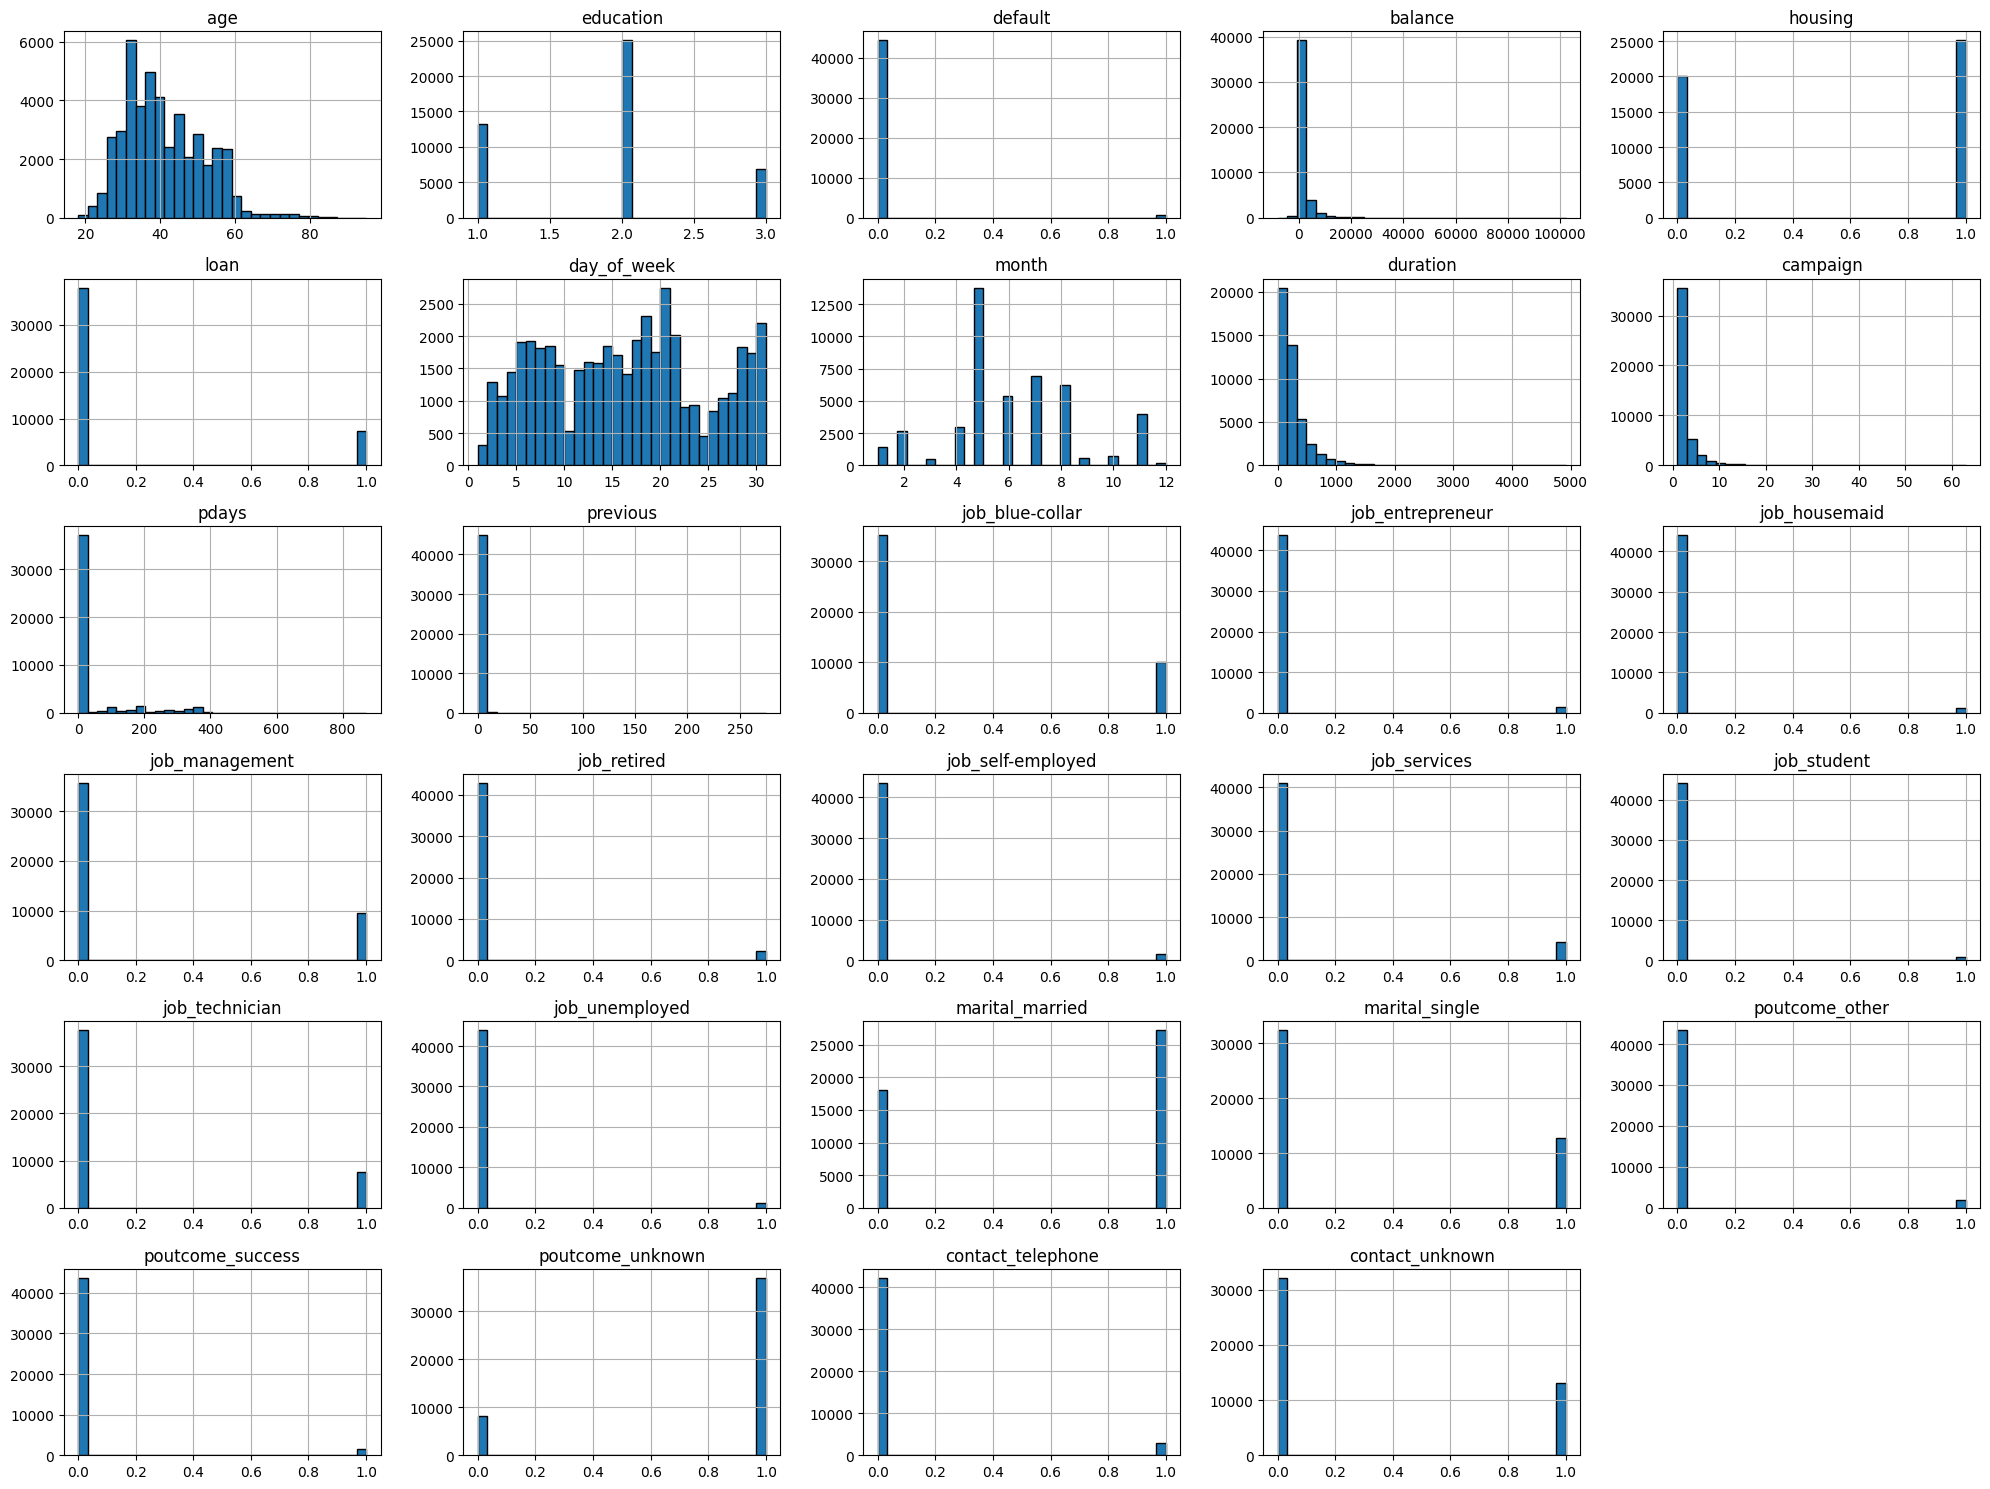

In [21]:
# Plot the distribution of every featureX.hist(figsize=(20, 15), bins=30, edgecolor='black')plt.tight_layout()plt.show()

# heat map

<Axes: >

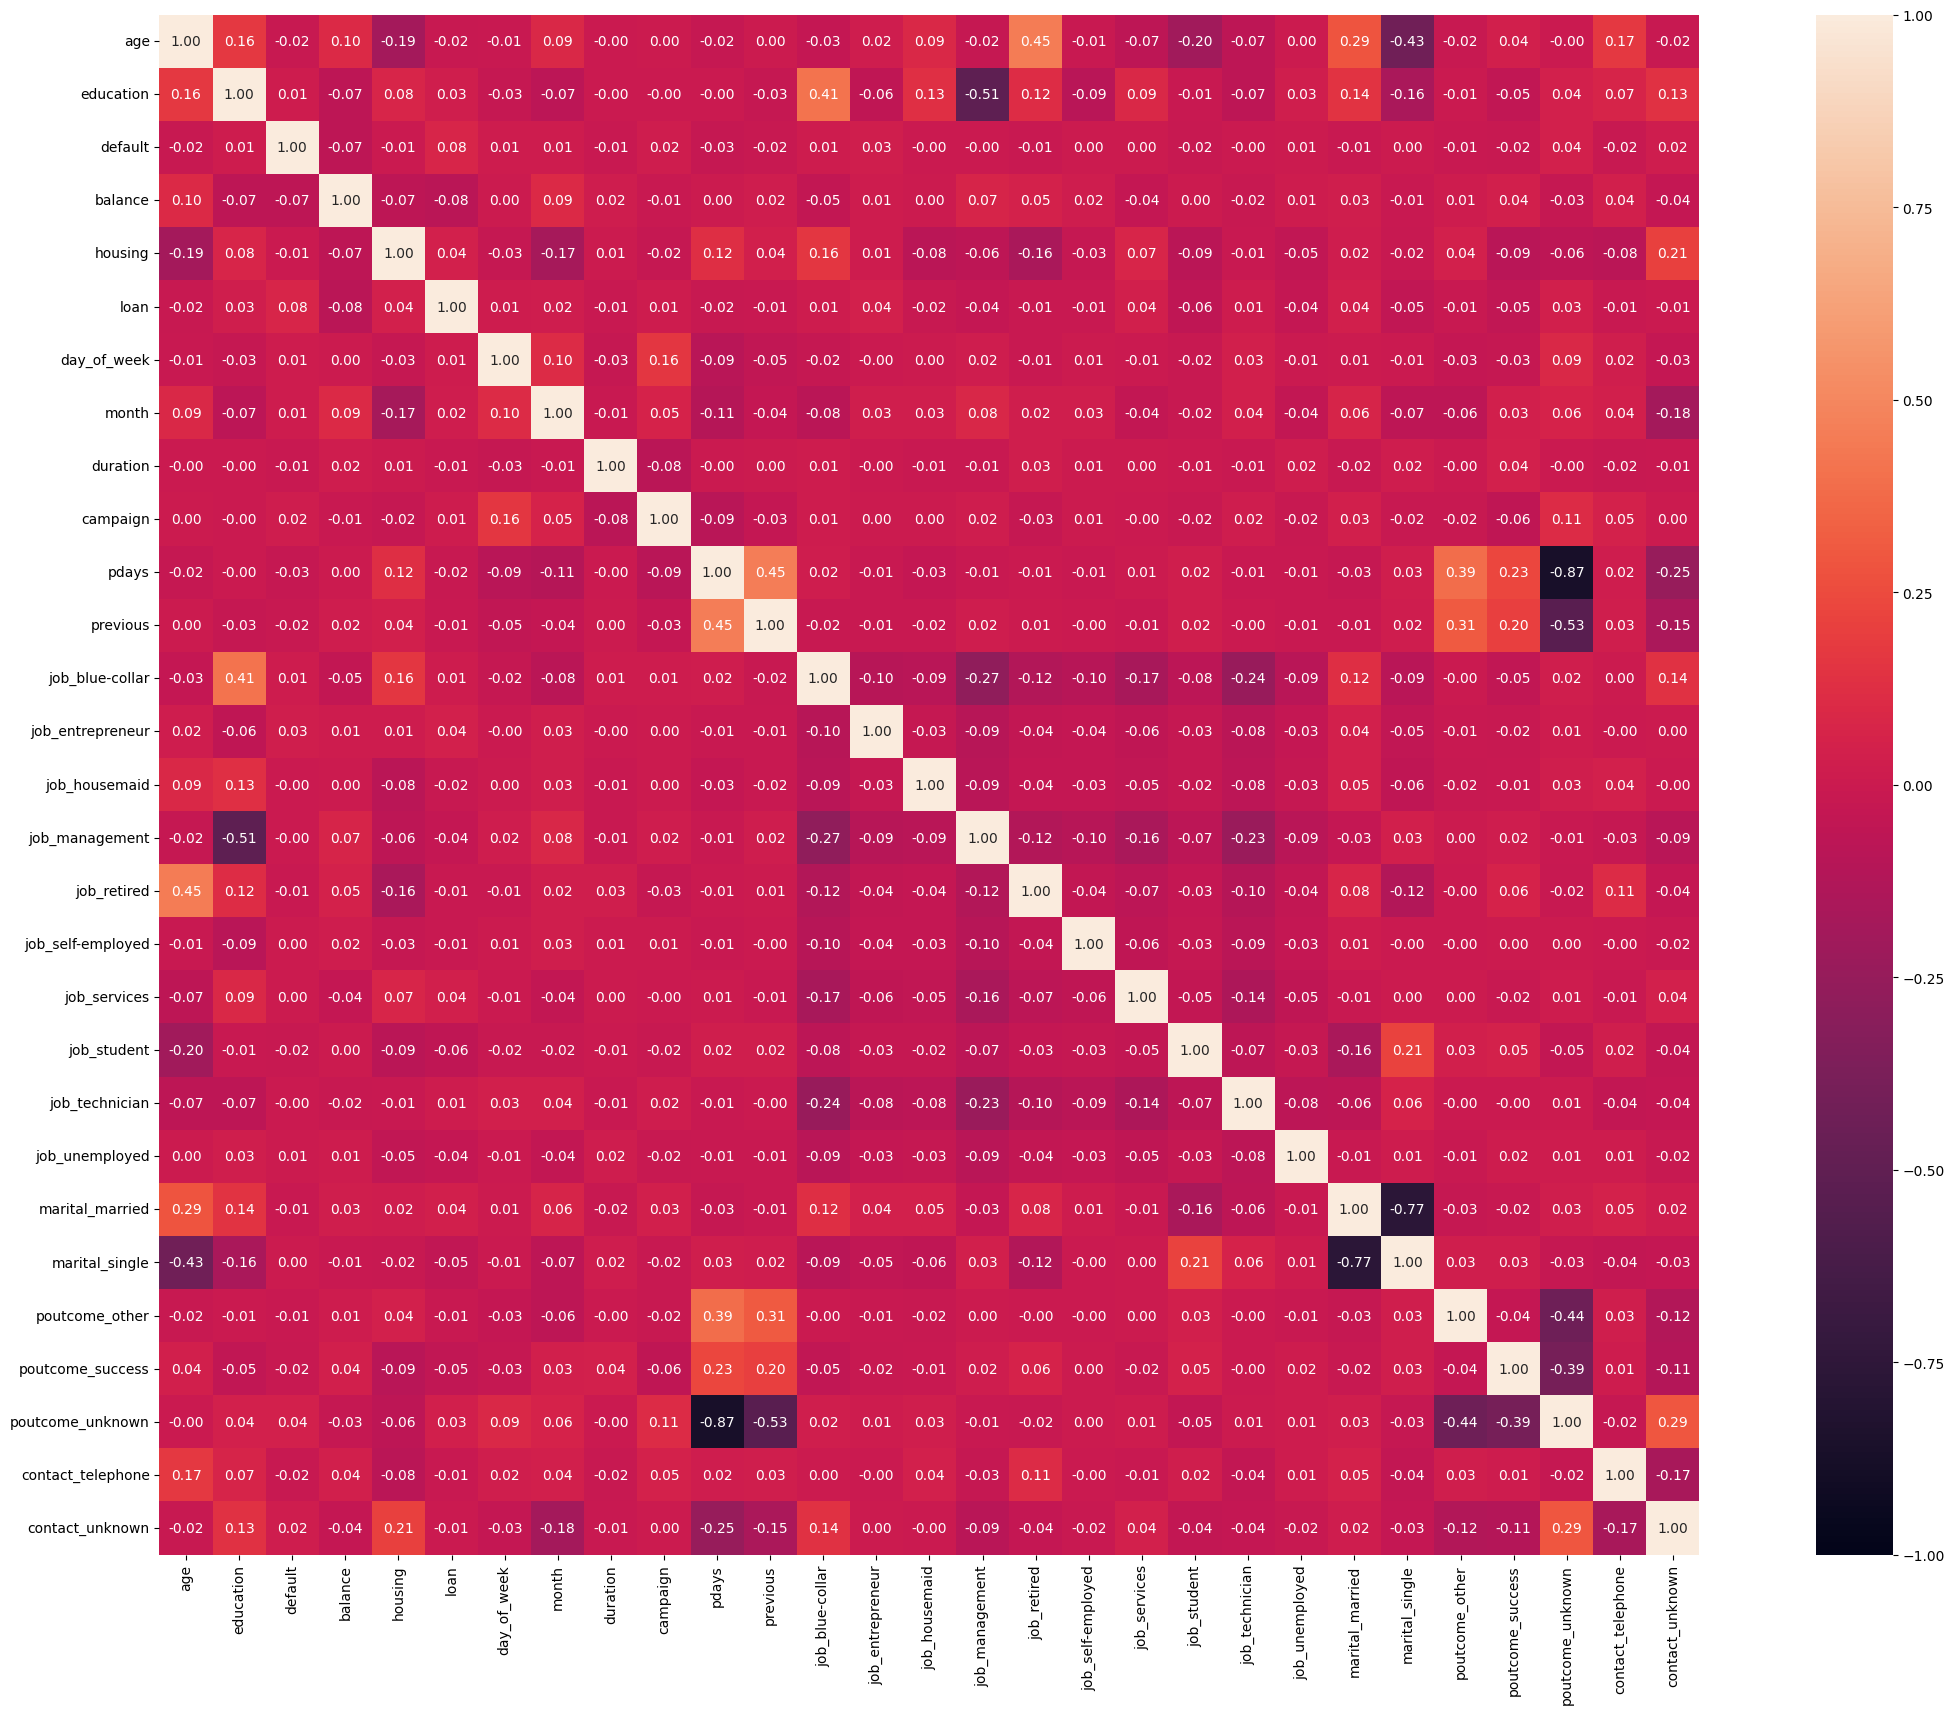

In [22]:
plt.figure(figsize=(30, 20))sns.heatmap(X.corr(numeric_only=True), annot=True, annot_kws={'size': 10}, fmt='.2f', square=True, vmax=1, vmin=-1)

In [25]:
X_scaled = MinMaxScaler().fit_transform(X)

In [26]:
X.shape

(45211, 29)

## Q1: Reduce dimensions to 8, 4, and 2. use a classifier on each and compare the performances. then compare the classification perfomance with and without dimension reduction

## SOM implementation

In [ ]:
class SelfOrganizingMap:    def __init__(self, input_dim, map_dim=(10, 10), learning_rate=0.5, sigma=None, num_iterations=100):        np.random.seed(42)        self.input_dim = input_dim        self.map_dim = map_dim if isinstance(map_dim, tuple) else (map_dim, 1) # it either has to be a tuple (x, y, etc) or it turns into a one dimensional map (e.g. (10, 1))        self.learning_rate = learning_rate        self.num_iterations = num_iterations        self.grid_shape = self.map_dim        self.sigma = sigma if sigma else max(self.map_dim) / 2.0 ## sigma is just the neighbourhood radius        self.weights = np.random.rand(self.grid_shape[0], self.grid_shape[1], self.input_dim)    def _find_bmu(self, x):        distances = np.linalg.norm(self.weights - x, axis=2) # Euclidean distance between the 'x' and all the 'weights'        return np.unravel_index(np.argmin(distances), self.grid_shape) # Returns the 2D coordinate of the BMU (smallest distance).x    def _update_weights(self, x, bmu_idx, iteration): ##  Updates weights using a Gaussian neighborhood centered on the BMU. (imagine a bell curve on the 'BMU' the curve gets less extream when you move further from the center (BMU), so less change is applied)        lr = self.learning_rate * np.exp(-iteration / self.num_iterations) ## lr and sigma decay over time        sigma = self.sigma * np.exp(-iteration / self.num_iterations)        # Create coordinate grid        x_coords, y_coords = np.meshgrid(np.arange(self.grid_shape[0]), np.arange(self.grid_shape[1]), indexing='ij')        # Distance squared from BMU        dist_sq = (x_coords - bmu_idx[0])**2 + (y_coords - bmu_idx[1])**2        neighborhood = np.exp(-dist_sq / (2 * sigma ** 2)).reshape(*self.grid_shape, 1) ## applying Gaussian neighborhood function        influence = lr * neighborhood # Influence of each node based on distance from BMU and lr        # Vectorized weight update        self.weights += influence * (x - self.weights)    def fit(self, X): # Train: For each input vector, find its BMU and update the weights.        for iteration in range(self.num_iterations):            for x in X:                bmu_idx = self._find_bmu(x)                self._update_weights(x, bmu_idx, iteration)    # Converts each data point into a one-hot vector of its BMU position.    def transform(self, X):        indices = [self._find_bmu(x) for x in X] # Get BMU index for each input.        one_hot = np.zeros((len(X), self.map_dim[0] * self.map_dim[1])) # One-hot encoding shape.        for idx, (i, j) in enumerate(indices): # One-hot encode BMU location for each input.            flat_index = i * self.map_dim[1] + j            one_hot[idx, flat_index] = 1        return one_hot    # Returns just the BMU coordinates for each input x.    def get_bmu_indices(self, X):        return np.array([self._find_bmu(x) for x in X])